# FairScreen Baseline – EDA of the Resume–Job Matching Dataset

This notebook explores and cleans the Kaggle `resume_data.csv` dataset by Saugata Roy Arghya , where each row pairs one candidate's CV with one job and a `matched_score`, to confirm it is workable for a naive keyword-matching baseline that ranks CVs by how many job keywords they contain.

In [1]:
import pandas as pd

df = pd.read_csv("../data/resume_data.csv", encoding="utf-8-sig")
print(df.shape)

(9544, 35)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    str    
 1   career_objective                     4740 non-null   str    
 2   skills                               9488 non-null   str    
 3   educational_institution_name         9460 non-null   str    
 4   degree_names                         9460 non-null   str    
 5   passing_years                        9460 non-null   str    
 6   educational_results                  9460 non-null   str    
 7   result_types                         9460 non-null   str    
 8   major_field_of_studies               9460 non-null   str    
 9   professional_company_names           9460 non-null   str    
 10  company_urls                         9460 non-null   str    
 11  start_dates                          9460

In [4]:
df.iloc[0]

address                                                                              NaN
career_objective                       Big data analytics working and database wareho...
skills                                 ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...
educational_institution_name           ['The Amity School of Engineering & Technology...
degree_names                                                                  ['B.Tech']
passing_years                                                                   ['2019']
educational_results                                                              ['N/A']
result_types                                                                      [None]
major_field_of_studies                                                   ['Electronics']
professional_company_names                                                 ['Coca-COla']
company_urls                                                                      [None]
start_dates          

### Findings from the first look

- **List-like text:** `skills` looks like a Python list (`['Big Data', 'Hadoop', ...]`) but is stored as a string. `related_skils_in_job` is a list inside a list (`[['Big Data']]`). These must be parsed before keywords can be counted.
- **Two kinds of missing values:** real blanks appear as `NaN`, but hidden blanks sit inside the text as `['N/A']` or `[None]` (e.g. `educational_results`, `locations`, `result_types`). `df.info()` counts these as non-null, so it understates how much data is missing.
- **Missing values come in blocks:** columns from the same CV section share the same non-null count: education and work history (9,460), extracurriculars (3,426), certifications (2,008), languages (700). When a CV lacks a section, all of that section's columns are empty together.
- **Duplicate column suspected:** in row 0, `responsibilities` and `responsibilities.1` contain the same text. This is checked across all rows in Section 2.
- **Hidden character in a column name:** column 28 appears as `job_position_name` with an invisible BOM character (`\ufeff`) in front of it, so it cannot be referenced by its normal name until fixed.
- **Early sign of a noisy score:** row 0 is a Big Data Analyst with an Electronics degree, scored **0.85** for a Senior Software Engineer job that has no `skills_required` listed.

In [6]:
same = (df["responsibilities"] == df["responsibilities.1"]).mean()
print(same)

1.0


In [7]:
job_cols = ["job_position_name", "educationaL_requirements", "experiencere_requirement",
            "age_requirement", "responsibilities.1", "skills_required"]
target = "matched_score"
cv_cols = [c for c in df.columns if c not in job_cols + [target, "responsibilities"]]
print(len(cv_cols), len(job_cols))

27 6


### Column map

Each row is **one CV paired with one job**, plus a score for how well they match. The 35 columns split into four groups:

| Group | Count | Columns | Role in this project |
|---|---|---|---|
| **Candidate (CV) side** | 27 | address, career_objective, skills, education (institution, degree, passing years, results, result types, major), work history (company names, URLs, start/end dates, related skills, positions, locations), extracurriculars (4), languages, proficiency levels, certifications (5) | Describes the applicant. `skills` and `related_skils_in_job` supply the CV keywords for the baseline. |
| **Job side** | 6 | job_position_name, educationaL_requirements, experiencere_requirement, age_requirement, responsibilities.1, skills_required | Describes the job. `job_position_name`, `skills_required` and `responsibilities.1` supply the job keywords. |
| **Target** | 1 | matched_score | The dataset's score (0–1) for how well the CV fits the job. Used to evaluate the baseline's ranking, never as an input. |
| **Duplicate (to drop)** | 1 | responsibilities | Looks like a CV field but is 100% identical to the job's `responsibilities.1`, so it carries no candidate information. |

Note: several column names contain typos from the source (`educationaL_requirements`, `experiencere_requirement`, `related_skils_in_job`). They are kept as-is for now and renamed during cleaning.

In [8]:
cv_text = df[cv_cols].fillna("").agg(" | ".join, axis=1)
df["cv_id"] = pd.factorize(cv_text)[0]

In [10]:
print("Unique CVs:", df["cv_id"].nunique())
print("Unique jobs:", df["job_position_name"].nunique())

Unique CVs: 344
Unique jobs: 28


In [11]:
print(df.groupby("job_position_name").size().describe())
print(df.groupby("cv_id").size().value_counts())

count     28.000000
mean     340.857143
std        0.650600
min      340.000000
25%      340.000000
50%      341.000000
75%      341.000000
max      342.000000
dtype: float64
28    339
10      1
12      1
6       1
4       1
20      1
Name: count, dtype: int64


In [12]:
print(df.duplicated(subset=["cv_id", "job_position_name"]).sum())

0


### Grid structure

The dataset has no candidate ID, so each unique CV was given a `cv_id` by combining all 27 CV-side columns.

- **344 unique CVs** and **28 unique jobs**.
- The data is almost a complete grid: **339 CVs are scored against all 28 jobs**; only 5 CVs appear for fewer jobs (4, 6, 10, 12 and 20).
- Every job has **340–342 candidate CVs**.
- **No CV–job pair appears twice**, so there are no duplicate or conflicting scores.

**Why this matters for the baseline:**
- This mirrors a real screening task: for each job, the same pool of ~341 applicants must be ranked. The baseline will therefore be evaluated **within each job** (rank its ~341 CVs, compare to `matched_score`), not across all 9,544 rows at once.
- Each CV appears up to 28 times. If any model is trained later, data must be split **by CV**, not by row, otherwise the same person appears in both training and test sets.

**Also noticed:** one job title has a trailing newline character (`'Manager- Human Resource Management (HRM)\n'`). This is fixed during cleaning.

In [14]:
cvs = df.drop_duplicates("cv_id")
jobs = df.drop_duplicates("job_position_name")
print(len(cvs), len(jobs))

344 28


In [15]:
real_missing = cvs[cv_cols].isna().mean() * 100

In [16]:
def is_hidden_blank(text):
    if pd.isna(text):
        return False
    cleaned = text.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    items = [item.strip().lower() for item in cleaned.split(",")]
    return all(item in ("n/a", "none", "") for item in items)

hidden_missing = cvs[cv_cols].map(is_hidden_blank).mean() * 100

In [17]:
missing = pd.DataFrame({"real_%": real_missing, "hidden_%": hidden_missing})
missing["total_%"] = missing["real_%"] + missing["hidden_%"]
missing = missing.round(1).sort_values("total_%")
missing

,real_%,hidden_%,total_%
educational_institution_name,0.9,0.3,1.2
skills,0.6,0.6,1.2
degree_names,0.9,0.3,1.2
positions,0.9,0.6,1.5
professional_company_names,0.9,0.9,1.7
start_dates,0.9,0.9,1.7
end_dates,0.9,2.6,3.5
major_field_of_studies,0.9,9.9,10.8
passing_years,0.9,11.9,12.8
related_skils_in_job,0.9,14.2,15.1


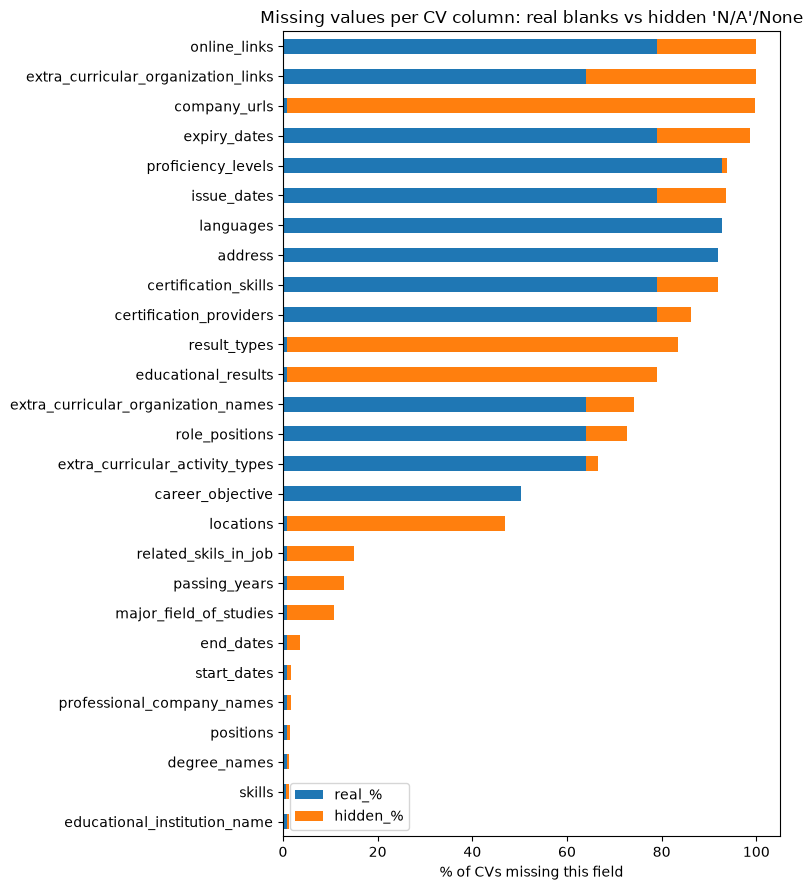

In [18]:
import matplotlib.pyplot as plt

missing[["real_%", "hidden_%"]].plot(kind="barh", stacked=True, figsize=(8, 9))
plt.xlabel("% of CVs missing this field")
plt.title("Missing values per CV column: real blanks vs hidden 'N/A'/None")
plt.tight_layout()
plt.show()

In [19]:
print(jobs[job_cols].isna().sum())
print(jobs.loc[jobs["skills_required"].isna(), "job_position_name"].tolist())

job_position_name            0
educationaL_requirements     0
experiencere_requirement     4
age_requirement             12
responsibilities.1           0
skills_required              5
dtype: int64
['Senior Software Engineer', 'Machine Learning (ML) Engineer', 'Executive/ Sr. Executive -IT', 'Intern (Generative AI Engineering - 2D/3D Image Generation)', 'Full Stack Developer (Python,React js)']


### Missing values

Missingness was measured **per unique CV (344)** and **per unique job (28)**, not per row, because each CV is repeated ~28 times and would otherwise be counted repeatedly.

Two kinds of missing value exist:
- **Real blanks** (`NaN`): the field is empty.
- **Hidden blanks**: the field contains text like `['N/A']` or `[None]`. `df.info()` counts these as filled, so it understates missingness. For example, `educational_results` looks 99% complete in `df.info()` but is actually **79% empty**.

**CV side, key findings:**

| Field | Total missing | Meaning for this project |
|---|---|---|
| `skills` | 1.2% | Main keyword source for the baseline is almost complete. |
| `related_skils_in_job` | 15.1% | Useful second keyword source, but patchy. |
| `positions`, `degree_names`, company names | 1–2% | Work history and degrees are well filled. |
| `major_field_of_studies` | 10.8% | Mostly present. |
| `career_objective` | 50.3% | Optional CV section; half of CVs have none. |
| `locations` | 46.8% | Almost all hidden `N/A`. |
| `educational_results` / `result_types` | 79–83% | **Grades are mostly absent**, so grade bias (FairScreen's concern with CHRIS) cannot be studied on this dataset. |
| Extracurriculars, certifications, languages, address | 66–94% | Optional sections that most CVs do not have. |
| `company_urls`, `online_links`, organization links | ~100% | Effectively empty; no analytical value. |

About 3 CVs (0.9%) have their entire education and work history blank.

**Job side:** all 28 jobs have a title, responsibilities and education requirement. But **5 jobs have no `skills_required`**: Senior Software Engineer, ML Engineer, Executive/Sr. Executive – IT, Generative AI Engineering Intern, and Full Stack Developer (all technical roles). Experience requirement is missing for 4 jobs and age requirement for 12.

**Decision for the baseline:** job keywords will come from `job_position_name` + `skills_required` + `responsibilities.1` combined, so the 5 jobs without listed skills still get keywords. CV keywords will come from `skills` + `related_skils_in_job`, the two most complete skill fields.

In [20]:
df["matched_score"].describe()

count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64

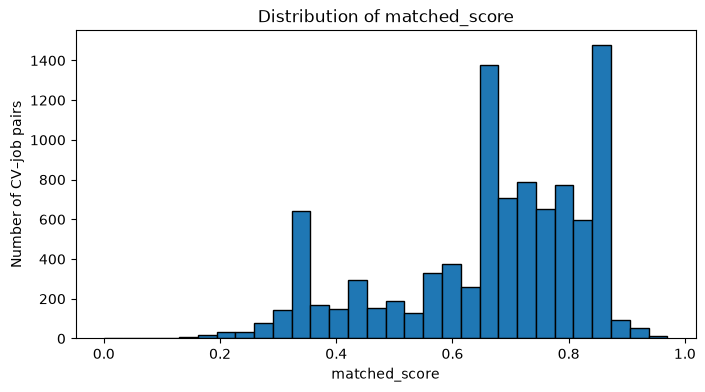

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(df["matched_score"], bins=30, edgecolor="black")
plt.xlabel("matched_score")
plt.ylabel("Number of CV–job pairs")
plt.title("Distribution of matched_score")
plt.show()

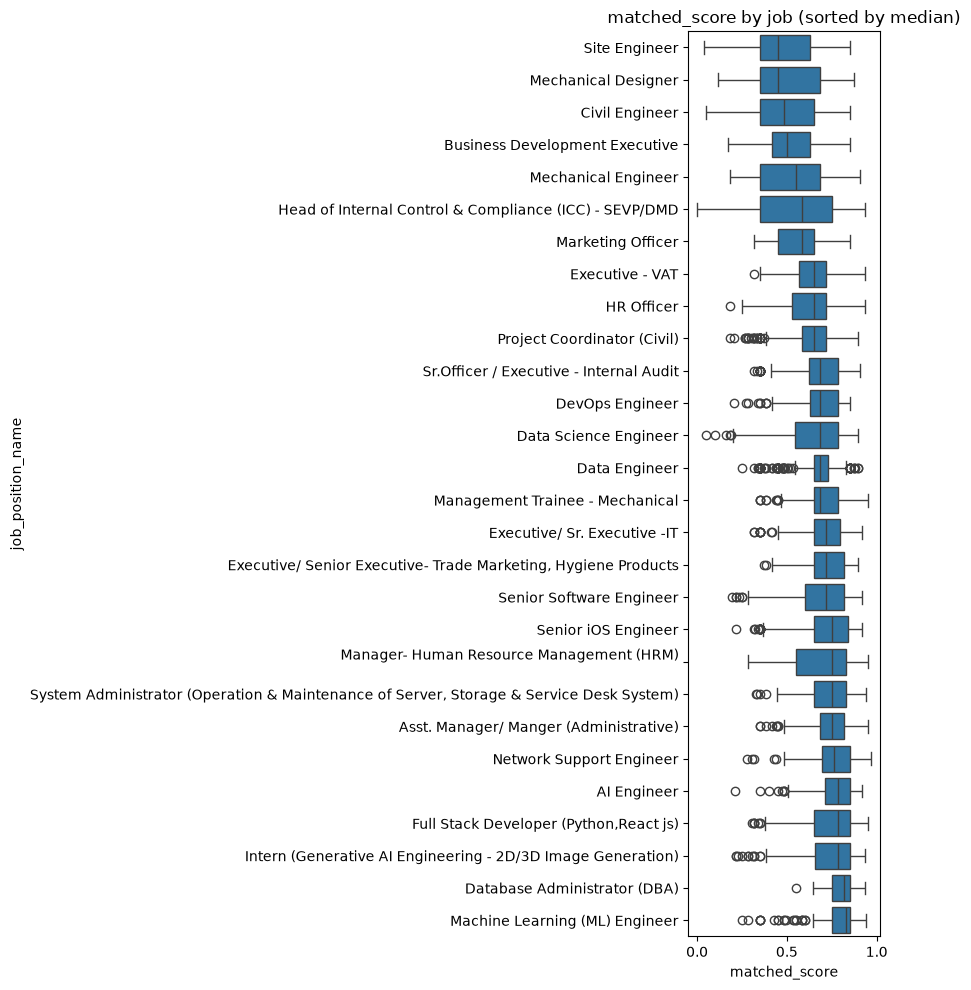

In [22]:
import seaborn as sns

order = df.groupby("job_position_name")["matched_score"].median().sort_values().index
plt.figure(figsize=(9, 10))
sns.boxplot(data=df, y="job_position_name", x="matched_score", order=order)
plt.title("matched_score by job (sorted by median)")
plt.tight_layout()
plt.show()

In [23]:
total_var = ((df["matched_score"] - df["matched_score"].mean()) ** 2).sum()

for group in ["job_position_name", "cv_id"]:
    group_mean = df.groupby(group)["matched_score"].transform("mean")
    explained = 1 - ((df["matched_score"] - group_mean) ** 2).sum() / total_var
    print(group, round(explained, 3))

job_position_name 0.284
cv_id 0.219


In [24]:
high_counts = df.groupby("cv_id")["matched_score"].apply(lambda s: (s >= 0.85).sum())
print(high_counts.sort_values(ascending=False).head())

example = df[df["cv_id"] == high_counts.idxmax()]
print(example[["positions", "major_field_of_studies"]].iloc[0])

cv_id
182    27
278    26
5      25
22     24
64     21
Name: matched_score, dtype: int64
positions                 ['Engineering and Quality Technician', 'Lectur...
major_field_of_studies    ['Analytics', 'Environmental Science and Techn...
Name: 246, dtype: str


### The target: `matched_score`

**Distribution:** scores range from 0 to 0.97, with mean 0.661 and median 0.683. They are compressed in the middle: **49% of all pairs score between 0.6 and 0.8**, only 12% score below 0.4, and fewer than 1% score 0.9 or above. The score rarely says "clearly unsuitable" or "clearly excellent".

**The job strongly affects the score.** Average scores range from **0.485 (Site Engineer)** to **0.795 (Database Administrator)**. Some jobs are scored generously for everyone, others harshly. Knowing only the job explains **28%** of the variation in scores; knowing only the CV explains **22%**, before any matching between the two is considered.

**Signs of noise:** one CV (engineering/quality technician and environmental science lecturer) scores **≥ 0.85 on 27 of its 28 jobs**, including HR, VAT, internal audit, iOS and civil engineering roles. A genuine fit score would not rate one person as a strong match for almost every job. Row 0 (a Big Data Analyst scored 0.85 for a Senior Software Engineer role) is another example.

**What this means for evaluation:**
- `matched_score` is a **noisy proxy for fit**, not a perfect ground truth. Baseline results should be read as approximate.
- Because some jobs are scored more generously than others, the baseline must be evaluated **within each job** (does it rank that job's ~341 CVs in a similar order to `matched_score`?), never by comparing raw scores across jobs.
- How `matched_score` was produced is not documented in the dataset. This is recorded as a limitation.

In [26]:
clean = df.copy()
clean["job_position_name"] = clean["job_position_name"].str.strip()
print(clean["job_position_name"].str.contains("\n").sum())

0


In [27]:
clean = clean.rename(columns={
    "educationaL_requirements": "educational_requirements",
    "experiencere_requirement": "experience_requirement",
    "related_skils_in_job": "related_skills_in_job",
    "responsibilities.1": "job_responsibilities",
})

In [28]:
clean = clean.drop(columns=["responsibilities", "company_urls",
                            "online_links", "extra_curricular_organization_links"])
print(clean.shape)

(9544, 32)


### Cleaning part A: structure

- Stripped a trailing newline from one job title (`Manager- Human Resource Management (HRM)`).
- Renamed columns with source typos: `educationaL_requirements` → `educational_requirements`, `experiencere_requirement` → `experience_requirement`, `related_skils_in_job` → `related_skills_in_job`, and `responsibilities.1` → `job_responsibilities` (to make clear it describes the job).
- Dropped 4 columns: `responsibilities` (100% duplicate of the job's responsibilities) and `company_urls`, `online_links`, `extra_curricular_organization_links` (~100% empty per CV).
- Cleaned data: 9,544 rows × 32 columns. The original `df` is kept unchanged.

In [29]:
import ast

def parse_list(text):
    if pd.isna(text):
        return []
    try:
        value = ast.literal_eval(text)
    except (ValueError, SyntaxError):
        return [text]
    return value if isinstance(value, list) else [value]

print(parse_list(clean["skills"].iloc[0])[:5])

['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce']


In [33]:
def flatten(items):
    result = []
    for item in items:
        if isinstance(item, list):
            result.extend(flatten(item))
        elif item is not None and str(item).strip().lower() not in ("n/a", "none", ""):
            result.append(str(item).strip())
    return result

clean["cv_skills"] = (clean["skills"].map(parse_list)
                      + clean["related_skills_in_job"].map(parse_list)).map(flatten)

In [34]:
import re

STOPWORDS = {"a", "an", "the", "and", "or", "of", "to", "in", "for", "with", "on", "at",
             "by", "from", "as", "is", "are", "be", "will", "etc", "other", "its", "it",
             "their", "all", "any", "such", "into", "within", "per", "via"}

def to_keywords(text):
    words = re.findall(r"[a-z][a-z0-9+#]*", str(text).lower())
    return {w for w in words if len(w) >= 2 and w not in STOPWORDS}

print(to_keywords("Human Resource Management (HRM), C++ and MS Excel"))

{'resource', 'excel', 'human', 'ms', 'c++', 'hrm', 'management'}
